# Vandalism Crime Analysis in Dallas

This notebook provides a comprehensive crime analysis of **DESTRUCTION/ DAMAGE/ VANDALISM OF PROPERTY** offenses in Dallas. The analysis includes:

1. **Descriptive Statistics** - Overview of vandalism counts and distributions
2. **Time Series Analysis** - Weekly/monthly trends and seasonal patterns
3. **Aoristic Analysis** - Time of day patterns (accounting for uncertain event times)
4. **Hotspot Mapping** - Identifying high-crime locations using DBScan clustering
5. **Location Type Analysis** - Where vandalism occurs most frequently

In [1]:
# Import required libraries
from crimepy import data, geo, aoristic, time
from crimepy.cdcplot import plt, add_logo
import pandas as pd
import numpy as np
import contextily as cx

## 1. Load and Filter Data

Load the Dallas crime data and filter to vandalism offenses (nibrs_cat = 2).

In [2]:
# Load Dallas crime data
df = data.load_dallas_data()
outline = data.load_dallas_border()

# Filter to vandalism offenses
vandalism = df[df['nibrs_cat'] == 2].copy()
print(f'Total vandalism offenses: {len(vandalism):,}')
print(f'Date range: {vandalism["begin"].min()} to {vandalism["begin"].max()}')
vandalism.head(3).T

Total vandalism offenses: 28,112
Date range: 2021-07-23 11:26:00 to 2024-07-21 20:47:00


,18,39,48
nibrs_cat,2,2,2
location,4,6,2
begin,2021-07-23 11:26:00,2021-07-23 12:45:00,2021-07-23 13:35:00
end,2021-07-23 12:35:00,2021-07-23 13:00:00,2021-07-23 13:35:00
address,8702 S POLK ST,1060 W KIEST BLVD,4700 ROSS AVE
lat,32.64376,32.705723,32.804955
lon,-96.839424,-96.839714,-96.77725
NIBR_DESC,DESTRUCTION/ DAMAGE/ VANDALISM OF PROPERTY,DESTRUCTION/ DAMAGE/ VANDALISM OF PROPERTY,DESTRUCTION/ DAMAGE/ VANDALISM OF PROPERTY
LOC_DESC,Gas/Convenience,Other,Bar/Restaurant
geometry,POINT (2479602.622140478 6921184.767997441),POINT (2479157.12559716 6943722.78046643),POINT (2497775.6154673416 6980128.200653911)


## 2. Descriptive Statistics

Examine the distribution of vandalism by location type.

Vandalism by Location Type:
LOC_DESC
Apartment/Residence    11266
Parking Lot             6723
Street                  2215
Commercial              2092
Outdoor                 1772
Other                    965
Store                    869
Bar/Restaurant           843
Gas/Convenience          828
Hotel/Motel              468
School                    71
Name: count, dtype: int64

Total: 28,112


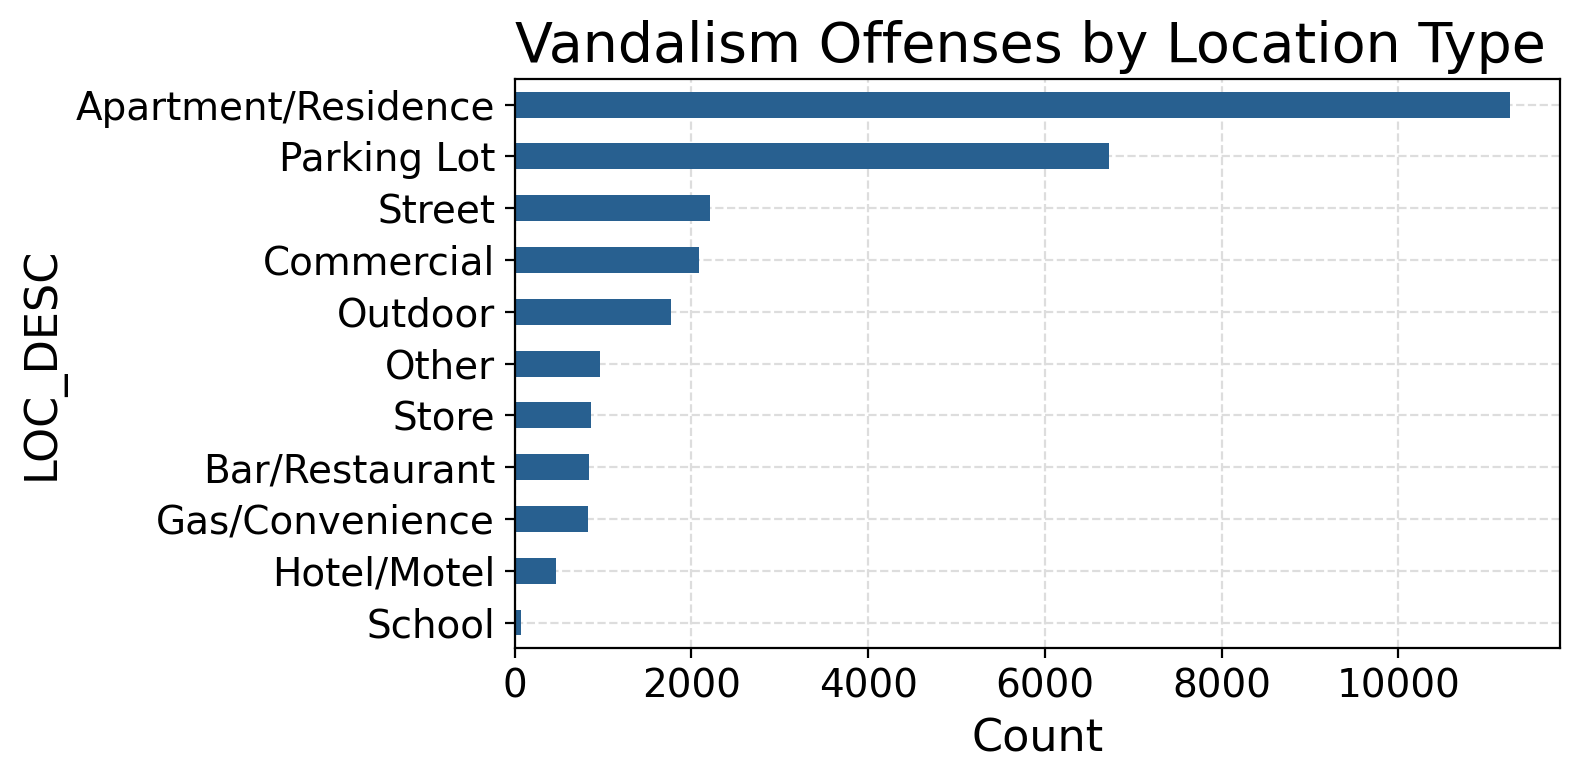

In [3]:
# Location type breakdown
loc_counts = vandalism['LOC_DESC'].value_counts()
print('Vandalism by Location Type:')
print(loc_counts)
print(f'\nTotal: {loc_counts.sum():,}')

# Bar chart of location types
fig, ax = plt.subplots(figsize=(8, 4))
loc_counts.plot(kind='barh', ax=ax, color='#286090')
ax.set_xlabel('Count')
ax.set_title('Vandalism Offenses by Location Type')
ax.invert_yaxis()
plt.tight_layout()

## 3. Time Series Analysis

Examine weekly and monthly trends in vandalism, plus seasonal patterns.

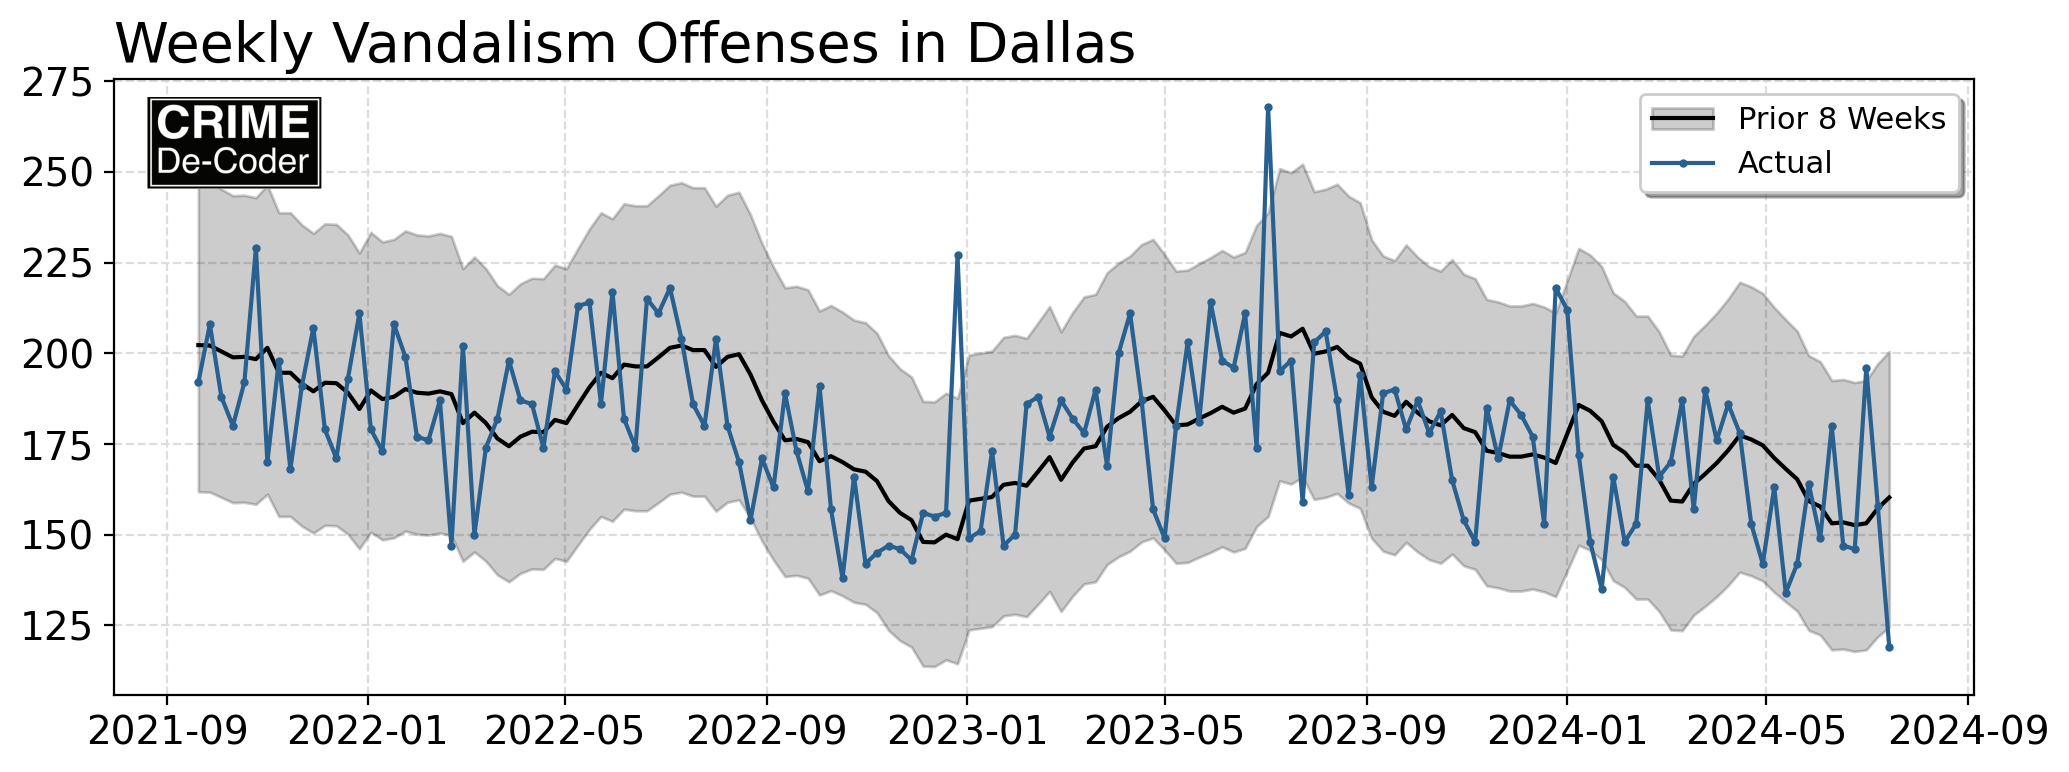

In [4]:
# Prepare time series data
vandalism['ReportDate'] = vandalism['begin'].dt.normalize()

# Weekly data
week_data = time.weekly_data(vandalism, 'ReportDate')

# Monthly data  
month_data = time.monthly_data(vandalism, 'ReportDate')

# Weekly chart
fig, ax = time.week_chart(week_data, 
                          title='Weekly Vandalism Offenses in Dallas',
                          legend_loc='upper right',
                          max_weeks=156,  # ~3 years
                          file='return')
add_logo(ax, loc=[-0.01, 0.82], size=0.15)

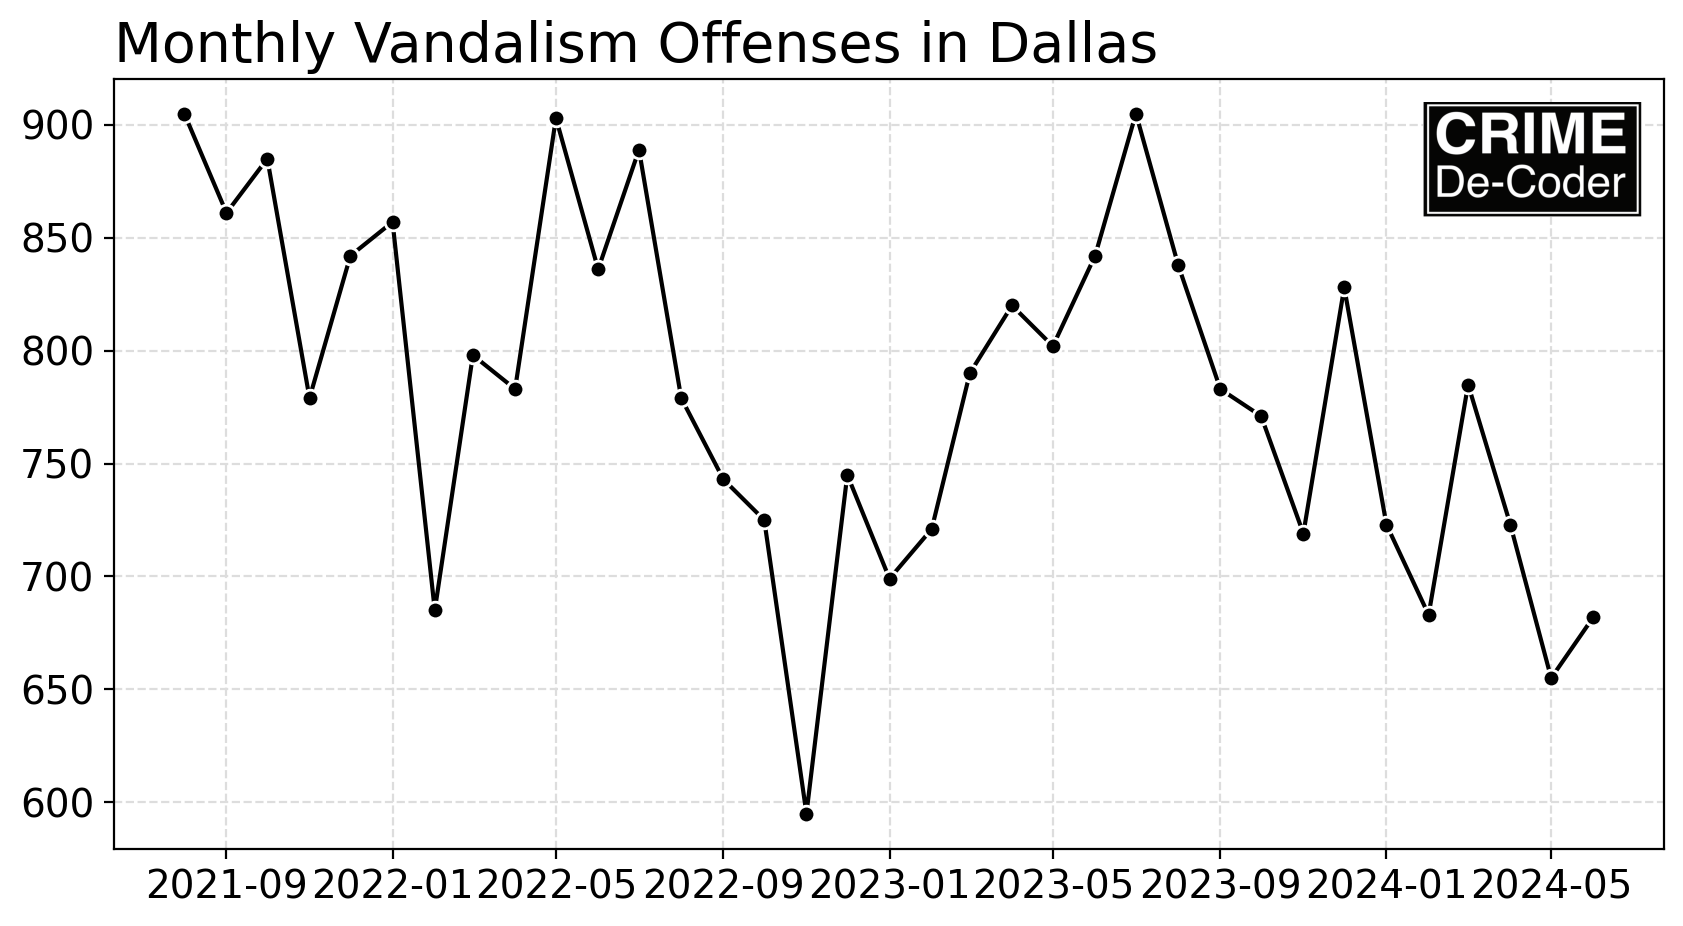

In [5]:
# Monthly chart
fig, ax = time.month_chart(month_data, 
                           title='Monthly Vandalism Offenses in Dallas',
                           file='return')
add_logo(ax, loc=[0.84, 0.82], size=0.15)

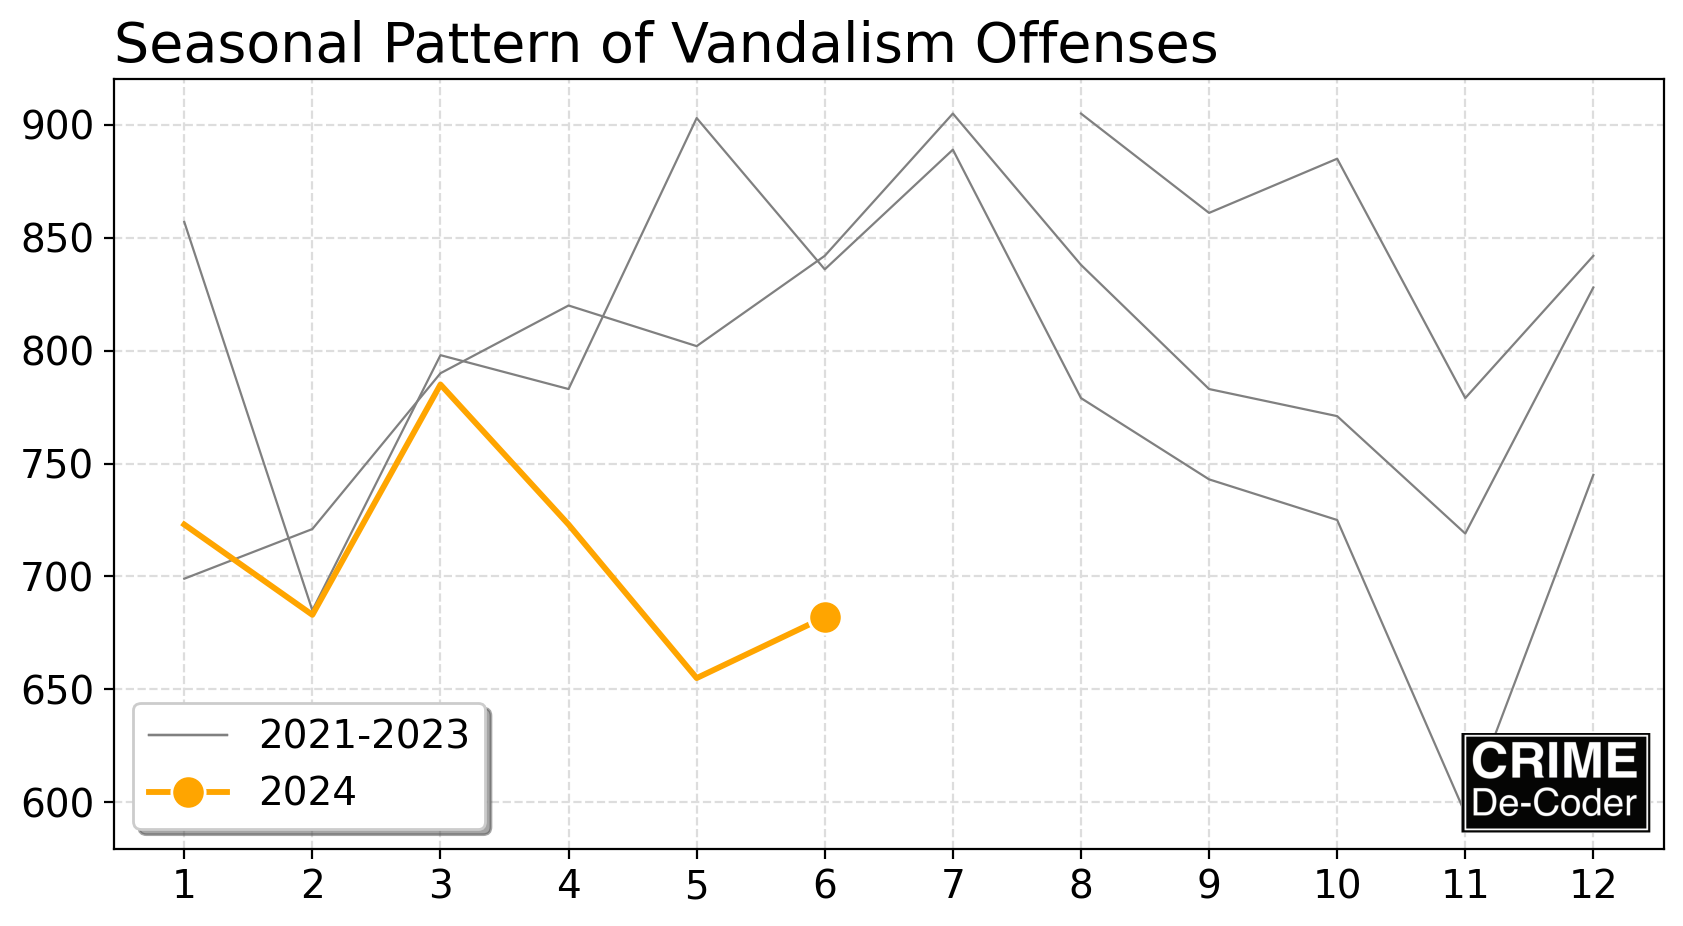

In [6]:
# Seasonal chart - compare patterns across years
fig, ax = time.seas_chart(month_data, 
                          title='Seasonal Pattern of Vandalism Offenses',
                          file='return')
add_logo(ax, loc=[0.865, 0.02], size=0.13)

In [7]:
# Monthly pivot table showing counts by year and month
month_data_copy = month_data.copy()
month_data_copy['Year'] = month_data_copy['Month'].dt.year
month_data_copy['MonthNum'] = month_data_copy['Month'].dt.month
mp = month_data_copy.pivot(index='MonthNum', columns='Year', values='Counts')
print('Monthly Vandalism Counts by Year:')
print(mp.to_markdown())

Monthly Vandalism Counts by Year:
|   MonthNum |   2021 |   2022 |   2023 |   2024 |
|-----------:|-------:|-------:|-------:|-------:|
|          1 |    nan |    857 |    699 |    723 |
|          2 |    nan |    685 |    721 |    683 |
|          3 |    nan |    798 |    790 |    785 |
|          4 |    nan |    783 |    820 |    723 |
|          5 |    nan |    903 |    802 |    655 |
|          6 |    nan |    836 |    842 |    682 |
|          7 |    nan |    889 |    905 |    nan |
|          8 |    905 |    779 |    838 |    nan |
|          9 |    861 |    743 |    783 |    nan |
|         10 |    885 |    725 |    771 |    nan |
|         11 |    779 |    595 |    719 |    nan |
|         12 |    842 |    745 |    828 |    nan |


## 4. Aoristic Analysis - Time of Day Patterns

Vandalism often has uncertain timing (discovered after the fact). Aoristic analysis distributes the probability across possible time windows.

In [8]:
# Check time uncertainty in vandalism data
time_dif = vandalism['end'] - vandalism['begin']
print('Distribution of time window (hours):')
print((time_dif.dt.seconds / (60*60)).describe())
prop_uncertain = (time_dif.dt.seconds > 0).mean()
print(f'\nProportion with uncertain time: {prop_uncertain:.2%}')

Distribution of time window (hours):
count    28112.000000
mean         3.837836
std          5.910309
min          0.000000
25%          0.066667
50%          0.500000
75%          6.000000
max         23.983333
dtype: float64

Proportion with uncertain time: 83.54%


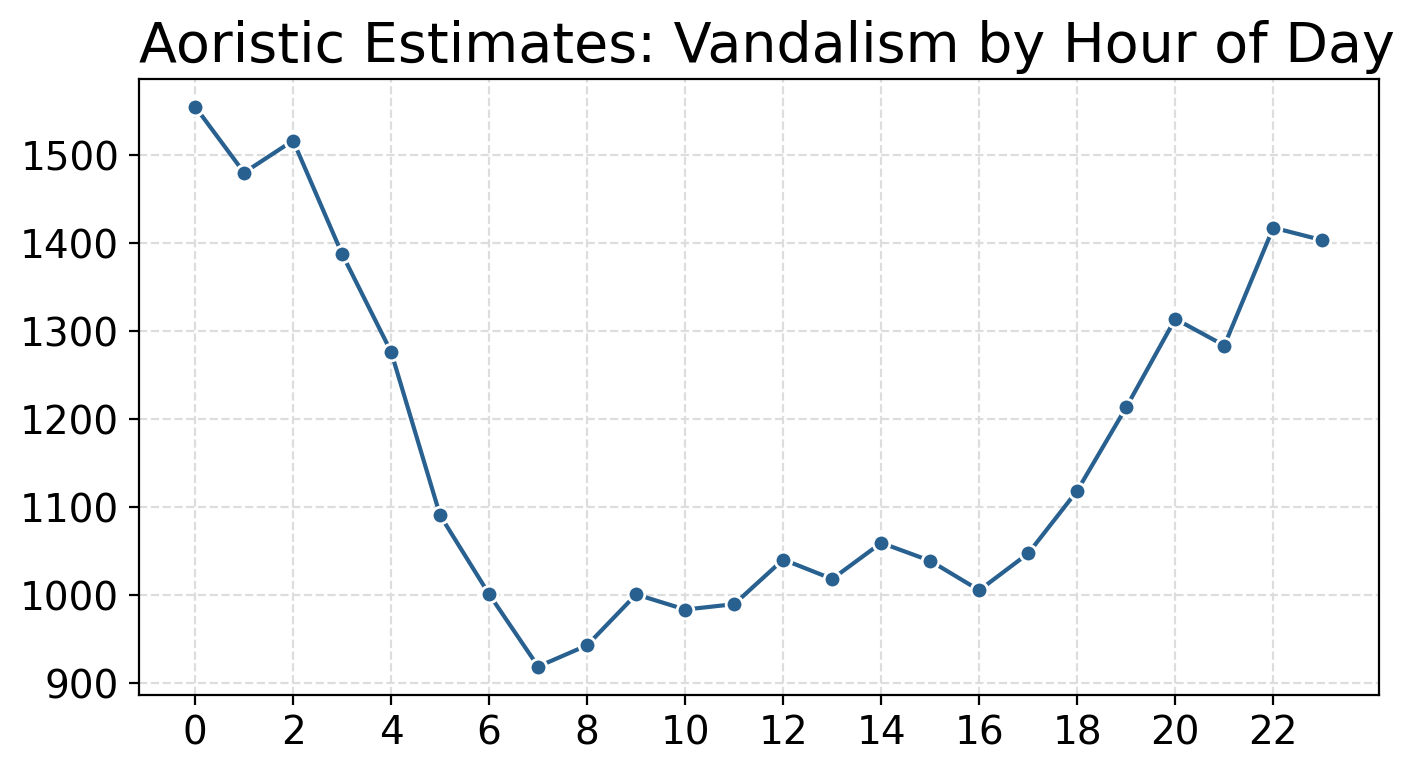

In [9]:
# Aoristic aggregation by hour and day of week
vand_aor = aoristic.agg_weekhour(vandalism, 'begin', 'end')

# Hour of day pattern (all days combined)
v_hour = vand_aor.groupby('hour', as_index=False)['weight'].sum()
aoristic.plt_basic(v_hour, show=False, 
                   title='Aoristic Estimates: Vandalism by Hour of Day',
                   color='#286090')

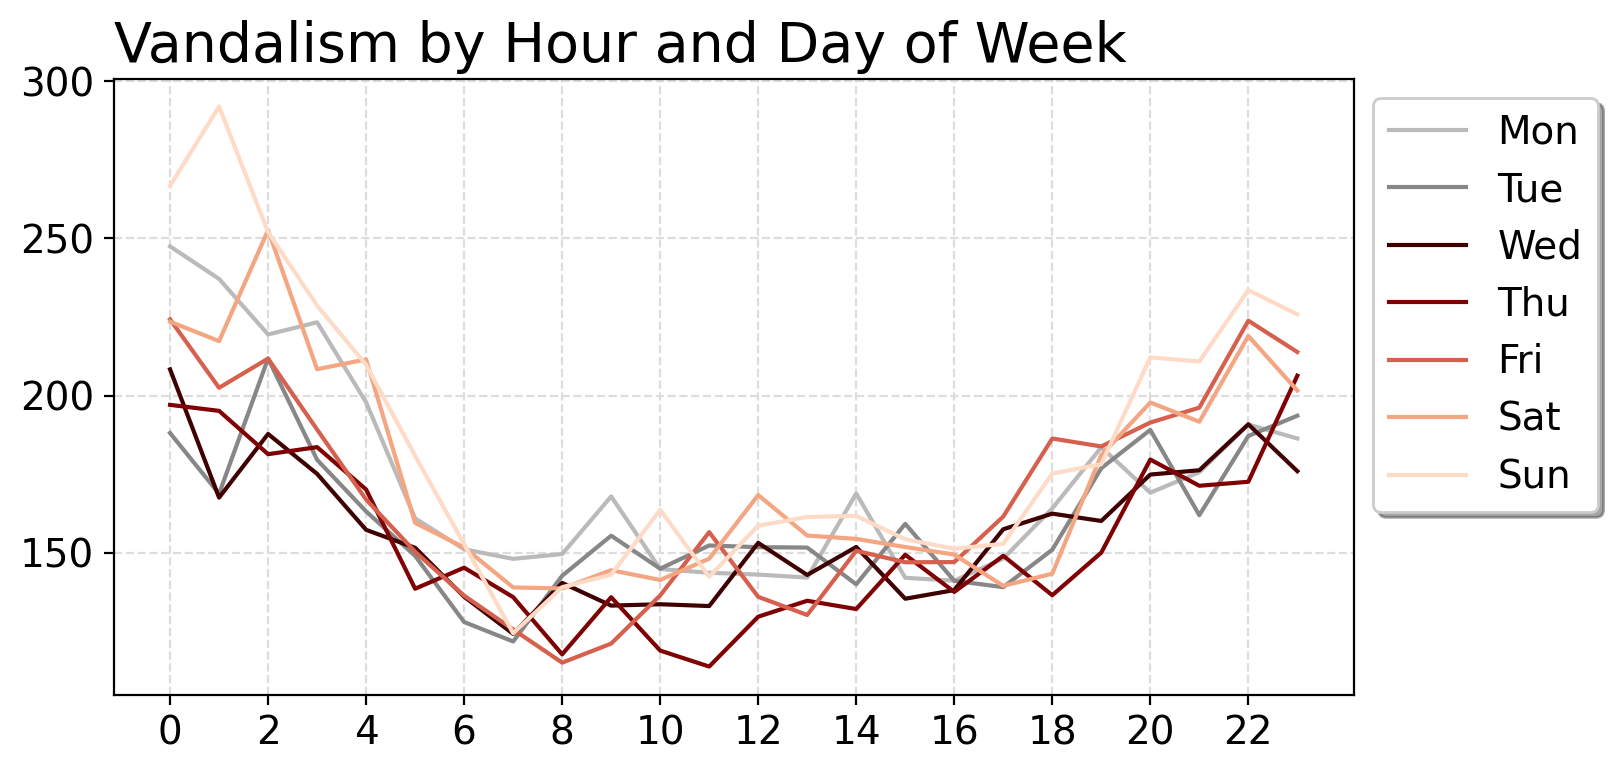

In [10]:
# Superimposed day of week pattern
aoristic.plt_super(vand_aor, show=False, 
                   title='Vandalism by Hour and Day of Week')

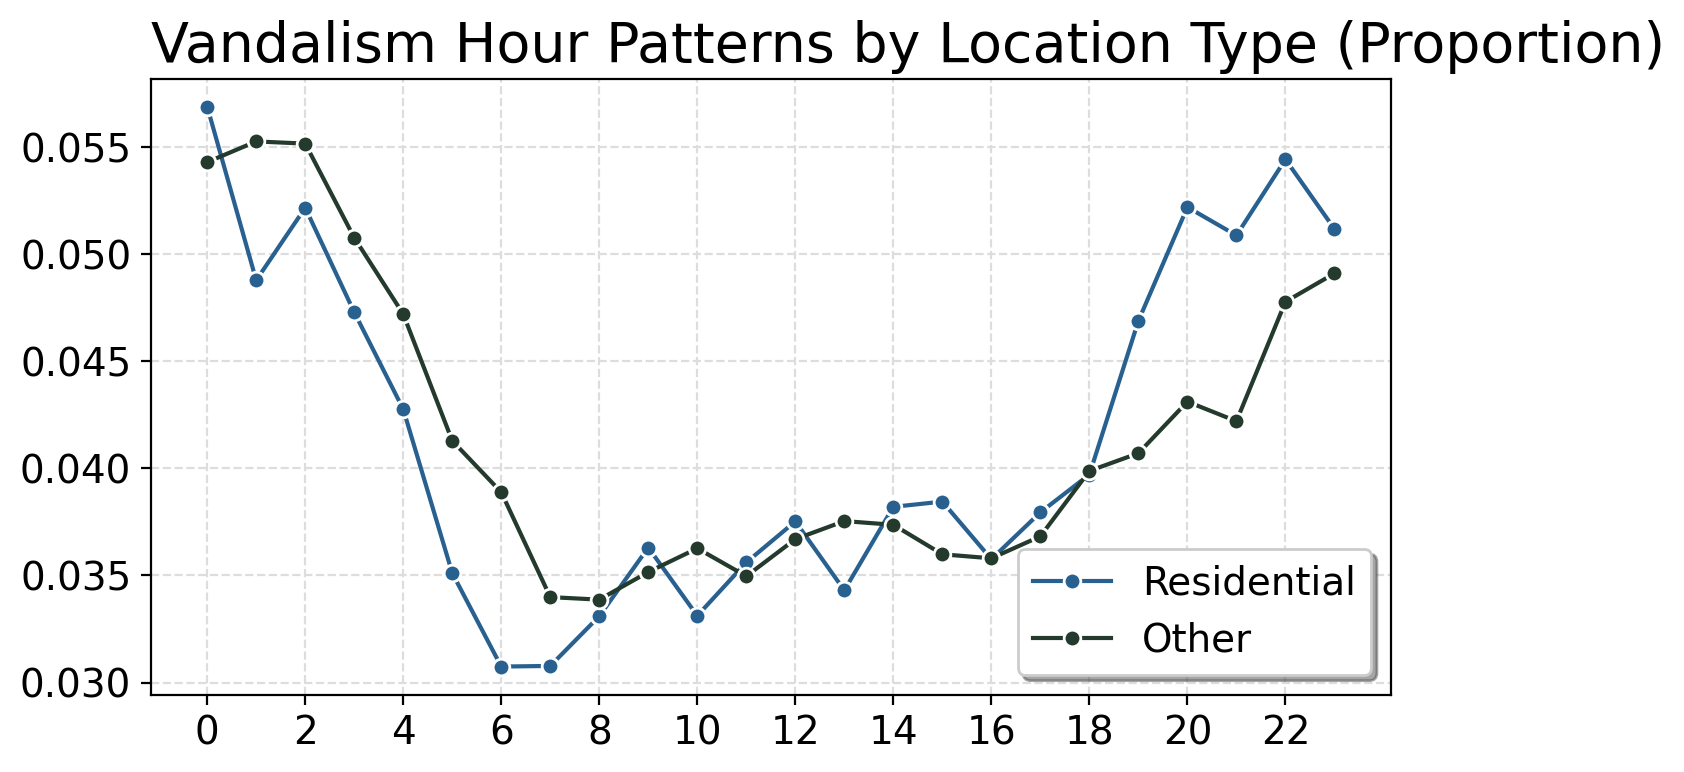

In [11]:
# Compare residential vs commercial vandalism patterns
vandalism['Type'] = vandalism['LOC_DESC'].apply(
    lambda x: 'Residential' if x == 'Apartment/Residence' else 'Other'
)
vand_by_type = aoristic.agg_weekhour(vandalism, 'begin', 'end', group=['Type'])

vand_res = vand_by_type[vand_by_type['Type'] == 'Residential'].copy()
vand_oth = vand_by_type[vand_by_type['Type'] == 'Other'].copy()

# Hour of day comparison
vr_hour = vand_res.groupby('hour', as_index=False)['weight'].sum()
vr_hour['weight'] = vr_hour['weight'] / vr_hour['weight'].sum()  # normalize to %
vo_hour = vand_oth.groupby('hour', as_index=False)['weight'].sum()
vo_hour['weight'] = vo_hour['weight'] / vo_hour['weight'].sum()

fig, ax = plt.subplots(figsize=(8, 4))
aoristic.plt_basic(vr_hour, show=False, ax=ax, color='#286090', 
                   label='Residential', title='Vandalism Hour Patterns by Location Type (Proportion)')
aoristic.plt_basic(vo_hour, show=False, ax=ax, color='#233A2D', label='Other')
ax.legend()

## 5. Hotspot Analysis - DBScan Clustering

Identify spatial clusters of vandalism using density-based clustering.

In [12]:
# DBScan hotspot detection
# distance in feet (data is projected in Texas North Central feet)
distance = 500  
min_samp = 100  # minimum points to form a cluster

print(f'Clustering with distance={distance} feet and min_samples={min_samp}')
hs_vand = geo.db_hotspots(vandalism, distance, min_samp)
print(f'\nFound {len(hs_vand)} hotspots')
hs_vand

Clustering with distance=500 feet and min_samples=100

Found 1 hotspots


,lab,geometry,weight
0,1,"POLYGON ((2491525.956 6971409.837, 2491523.549...",101


[]

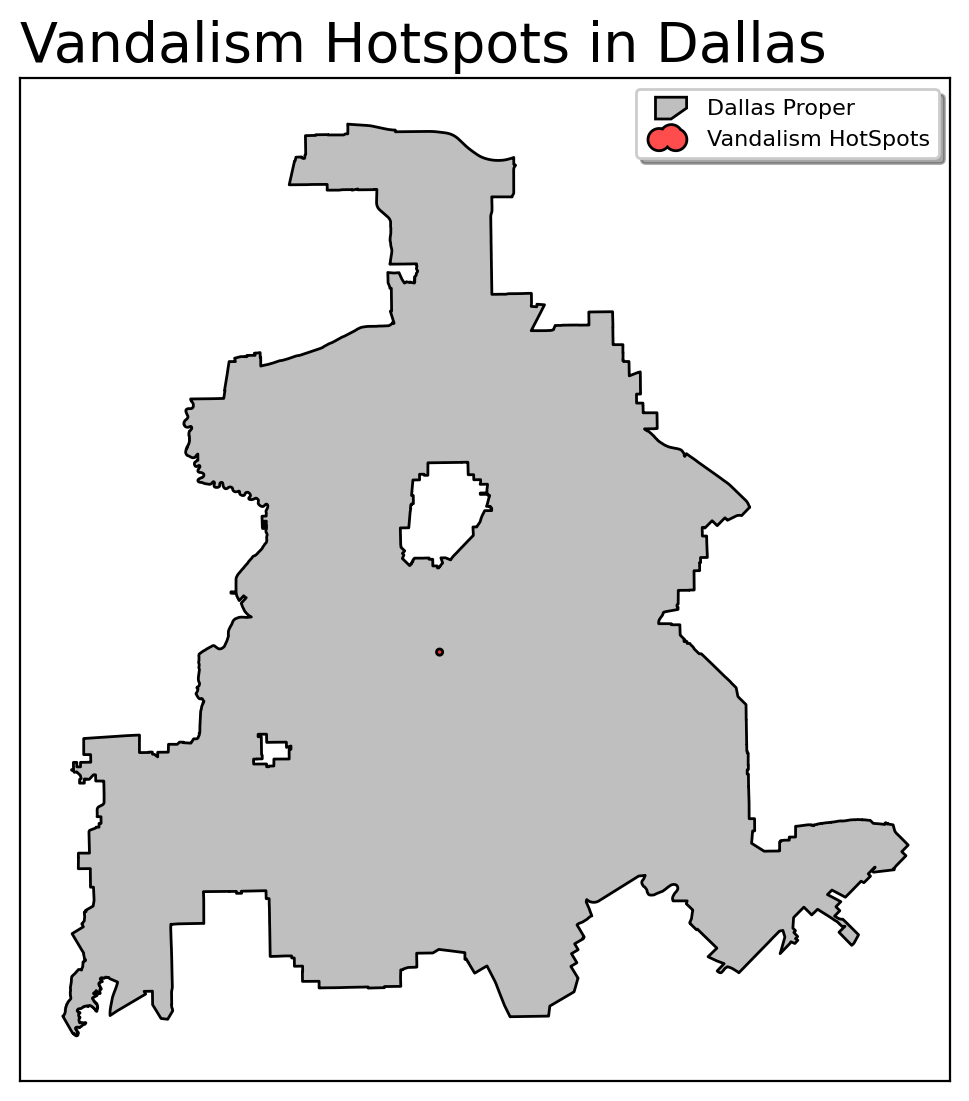

In [13]:
# Static map of hotspots
fig, ax = plt.subplots(figsize=(6, 12))
hm = {}
bn, bh = geo.geo_map(outline, ax, fill='grey', fill_alpha=0.5)
hn, hh = geo.geo_map(hs_vand, ax, fill='red', fill_alpha=0.7, leg_type='HotSpot')
hm[bn] = bh
hm[hn] = hh

ax.legend(hm.keys(), ['Dallas Proper', 'Vandalism HotSpots'], 
          handler_map=hm, loc='upper right', fontsize=8)
ax.set_title('Vandalism Hotspots in Dallas')
ax.get_xaxis().set_ticks([])
ax.get_yaxis().set_ticks([])

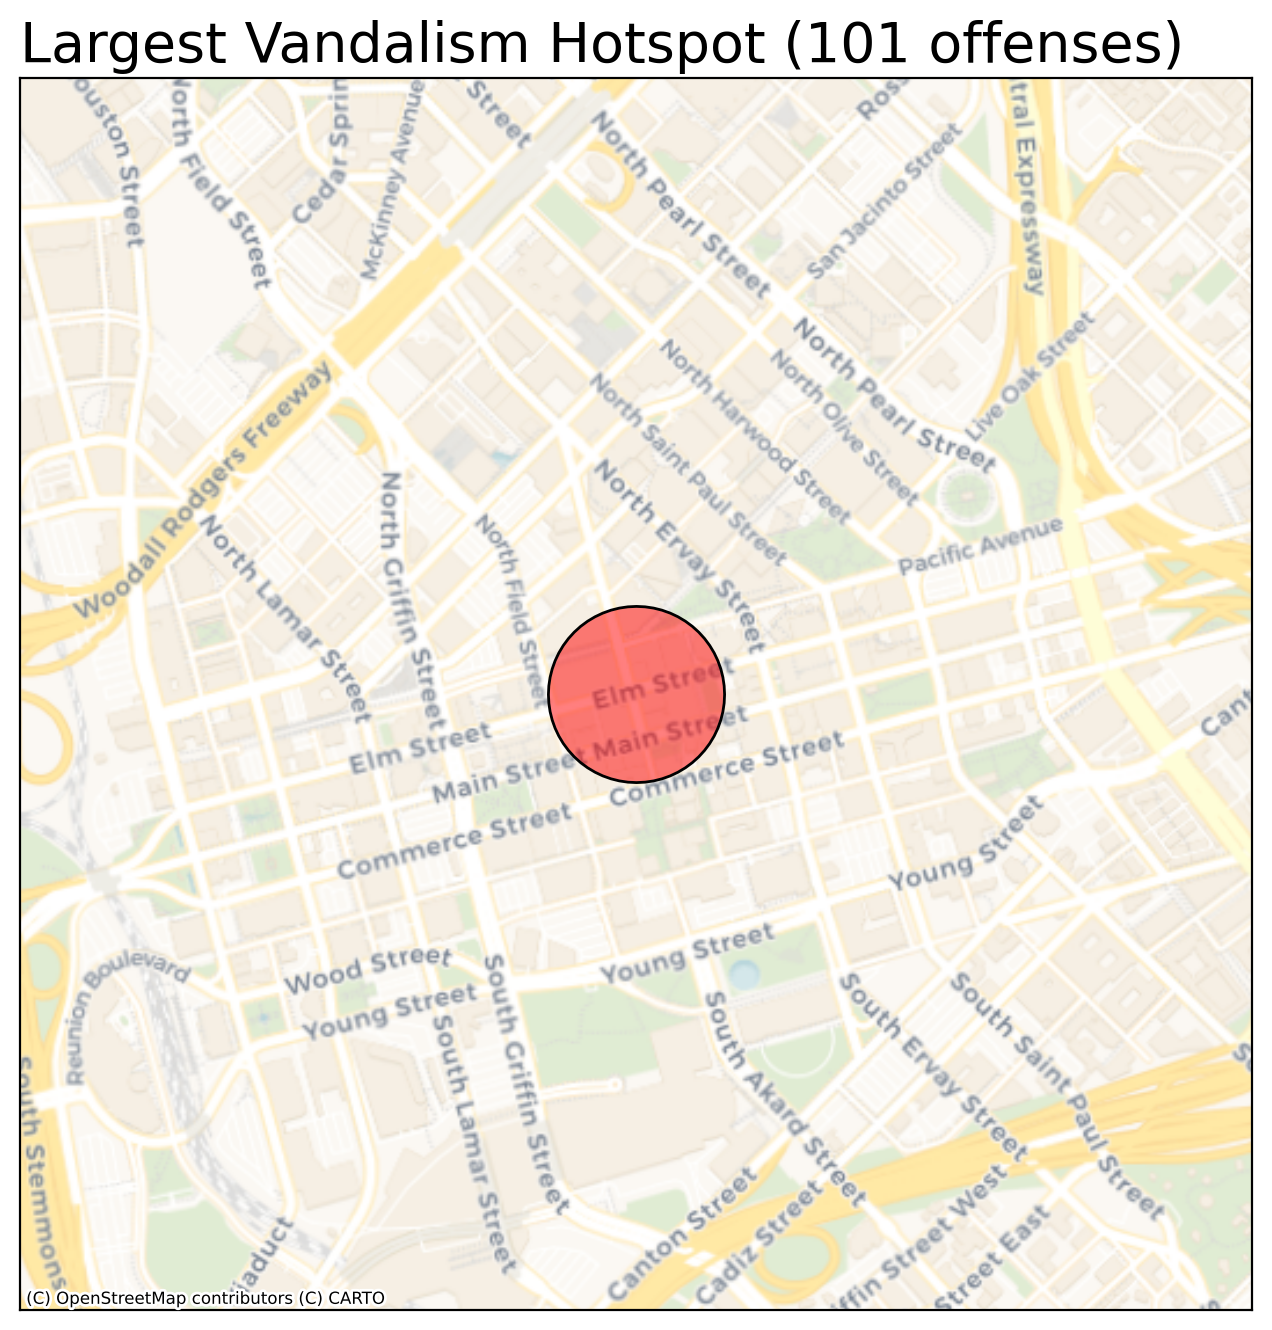

In [14]:
# Zoom in on the largest hotspot with basemap
if len(hs_vand) > 0:
    biggest_hs = hs_vand.loc[[0]].buffer(3000)
    bh_bound = biggest_hs[0].bounds
    xlim = (bh_bound[0], bh_bound[2])
    ylim = (bh_bound[1], bh_bound[3])

    fig, ax = plt.subplots(figsize=(8, 8))
    bn, bh = geo.geo_map(outline, ax, fill='none')
    hn, hh = geo.geo_map(hs_vand, ax, fill='red', fill_alpha=0.5, leg_type='HotSpot')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    cx.add_basemap(ax, crs=outline.crs.to_string(), 
                   source=cx.providers.CartoDB.Voyager, zoom=15,
                   attribution_size=6)
    ax.set_title(f'Largest Vandalism Hotspot ({hs_vand.loc[0, "weight"]:,} offenses)')
    ax.get_xaxis().set_ticks([])
    ax.get_yaxis().set_ticks([])

In [15]:
# Interactive Folium map
basemap = geo.base_folium(boundary=outline, legend_name='Dallas Proper')
geo.add_hotspots(basemap, hs_vand, ['weight'])
res = geo.save_map(basemap, file=None)
basemap

## 6. Summary Statistics

Year-to-date comparison statistics.

In [16]:
# Create category column for YTD stats
vandalism['Category'] = 'Vandalism'

# Add location type as a dummy for breakdown
loc_dummies = pd.get_dummies(vandalism['LOC_DESC'], prefix='', prefix_sep='')

# YTD stats by location type
ytd_stats, last_date = time.ytd_stats(vandalism, 'ReportDate', 'LOC_DESC')
print(f'Year-to-Date Statistics as of {last_date}')
print(ytd_stats.to_markdown(index=False))

Year-to-Date Statistics as of 2024-07-20
| LOC_DESC            |   2024 |   2023 |   Difference |   PoissonZ |
|:--------------------|-------:|-------:|-------------:|-----------:|
| Apartment/Residence |   1927 |   2187 |         -260 |   -5.73553 |
| Bar/Restaurant      |    173 |    156 |           17 |    1.3259  |
| Commercial          |    330 |    402 |          -72 |   -3.76807 |
| Gas/Convenience     |    145 |    173 |          -28 |   -2.2227  |
| Hotel/Motel         |     78 |    107 |          -29 |   -3.02464 |
| Other               |    158 |    188 |          -30 |   -2.28301 |
| Outdoor             |    292 |    313 |          -21 |   -1.2076  |
| Parking Lot         |   1008 |   1253 |         -245 |   -7.29745 |
| School              |     16 |      9 |            7 |    2       |
| Store               |    168 |    136 |           32 |    2.59916 |
| Street              |    424 |    381 |           43 |    2.14408 |


## Key Findings

This notebook analyzed vandalism offenses in Dallas. Key outputs include:

- **Time trends** showing weekly/monthly patterns and any seasonal effects
- **Aoristic analysis** revealing when vandalism most likely occurs (accounting for time uncertainty)
- **Spatial hotspots** identifying high-crime locations for targeted intervention
- **Location type breakdown** showing where vandalism is most common

These findings can inform patrol deployment, prevention strategies, and resource allocation.